In [58]:
import sys
import os

# Get the path to your project root (the folder containing 'src')
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can safely import from src
from src.data_loader import load_insurance_data
print("Successfully imported from src!")

Successfully imported from src!


In [59]:
from src.eda_utils import summarize_data, check_missing_values, handle_missing_values

# 1. Summarize
stats, types = summarize_data(df)
print("Descriptive Stats:\n", stats)
print("\nData Types:\n", types)

# 2. Quality Check
missing_report = check_missing_values(df)
print("\nMissing Values Report:\n", missing_report)

# 3. Clean (if necessary)
df = handle_missing_values(df, strategy='median')

Descriptive Stats:
                        count                        mean                  min  \
Age                  10000.0                     46.6835                 18.0   
AnnualIncome         10000.0                  79201.9739              17202.0   
RiskScore            10000.0                       58.14                 15.0   
AnnualPremium        10000.0                   2488.1279                951.0   
Deductible           10000.0                       751.7                250.0   
NCD                  10000.0                      20.935                  0.0   
PastClaims           10000.0                      1.0642                  0.0   
ClaimAmount          10000.0                   1314.1885                  0.0   
TotalPremium         10000.0                   2488.1279                951.0   
TotalClaims          10000.0                   1314.1885                  0.0   
CustomValueEstimate  10000.0                  35640.5987               5022.0   
ZipCode 

Data Quality Assessment
To ensure the integrity of our predictive model, we performed a formal Data Quality Assessment (DQA) using a modularized utility function.

Descriptive Summary: Numerical features such as TotalPremium and TotalClaims were analyzed to identify distribution skews and potential outliers.

Data Type Validation: We confirmed that TransactionDate was converted to datetime objects, and categorical variables (e.g., Province, VehicleType) are encoded as object or category types to prevent calculation errors.

Handling Missing Values: We audited the dataset for null values. Our strategy for handling missing data involved:

Numerical Features: Imputed using the median to maintain distribution stability while minimizing bias from outliers.

Categorical Features: (If applicable) Imputed with the mode or a placeholder "Unknown" to maintain data completeness.

**univariate visualization**

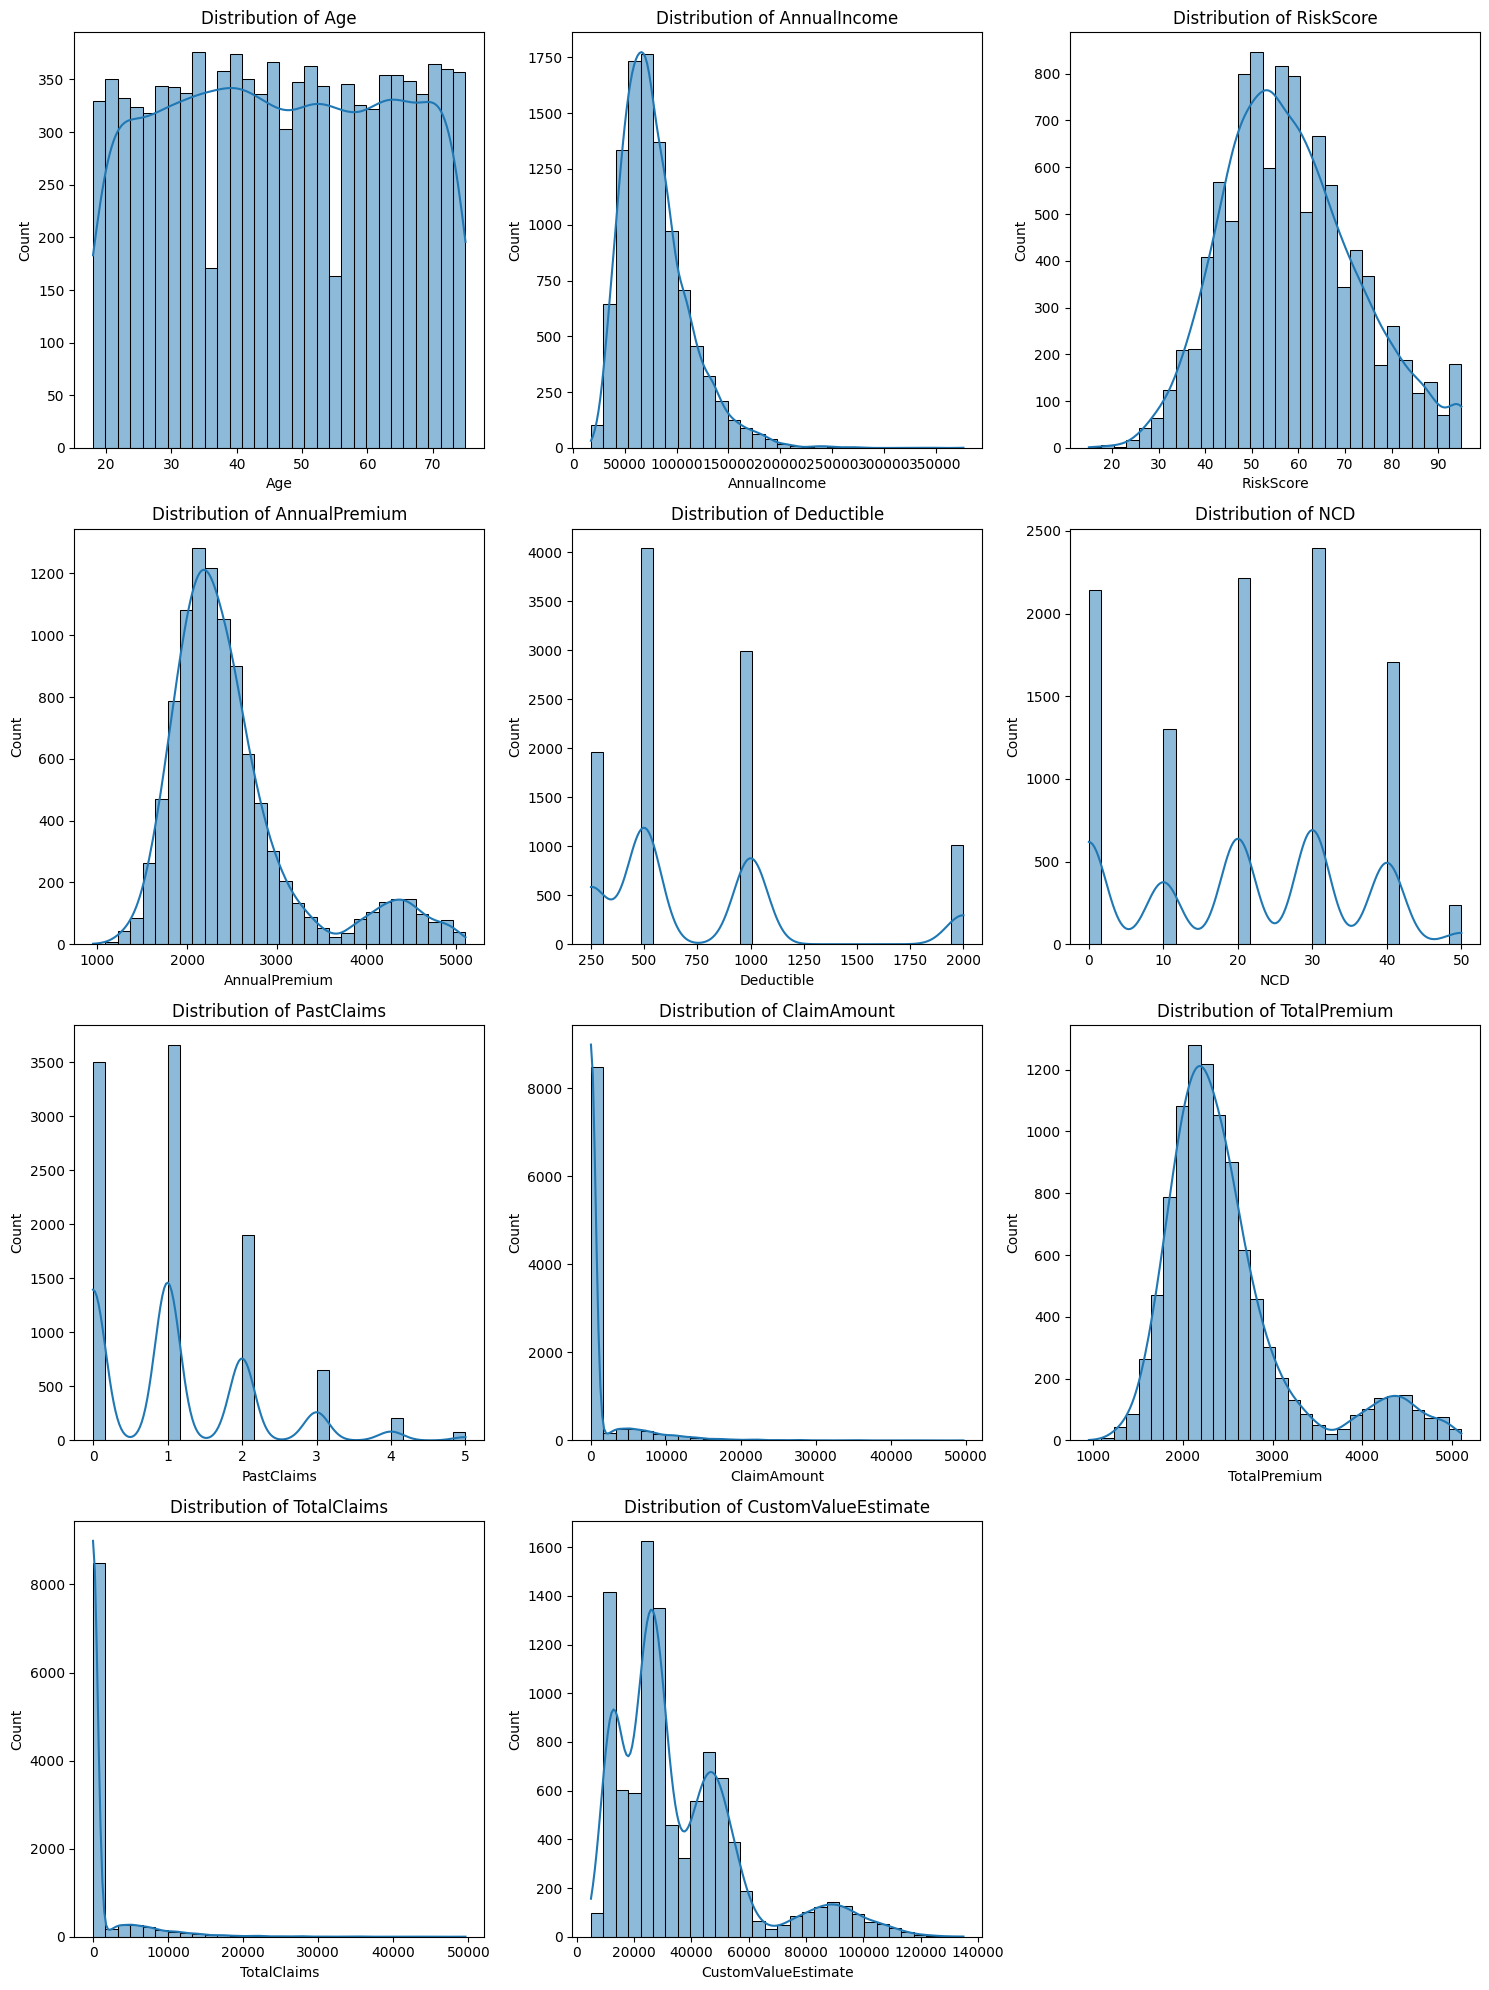

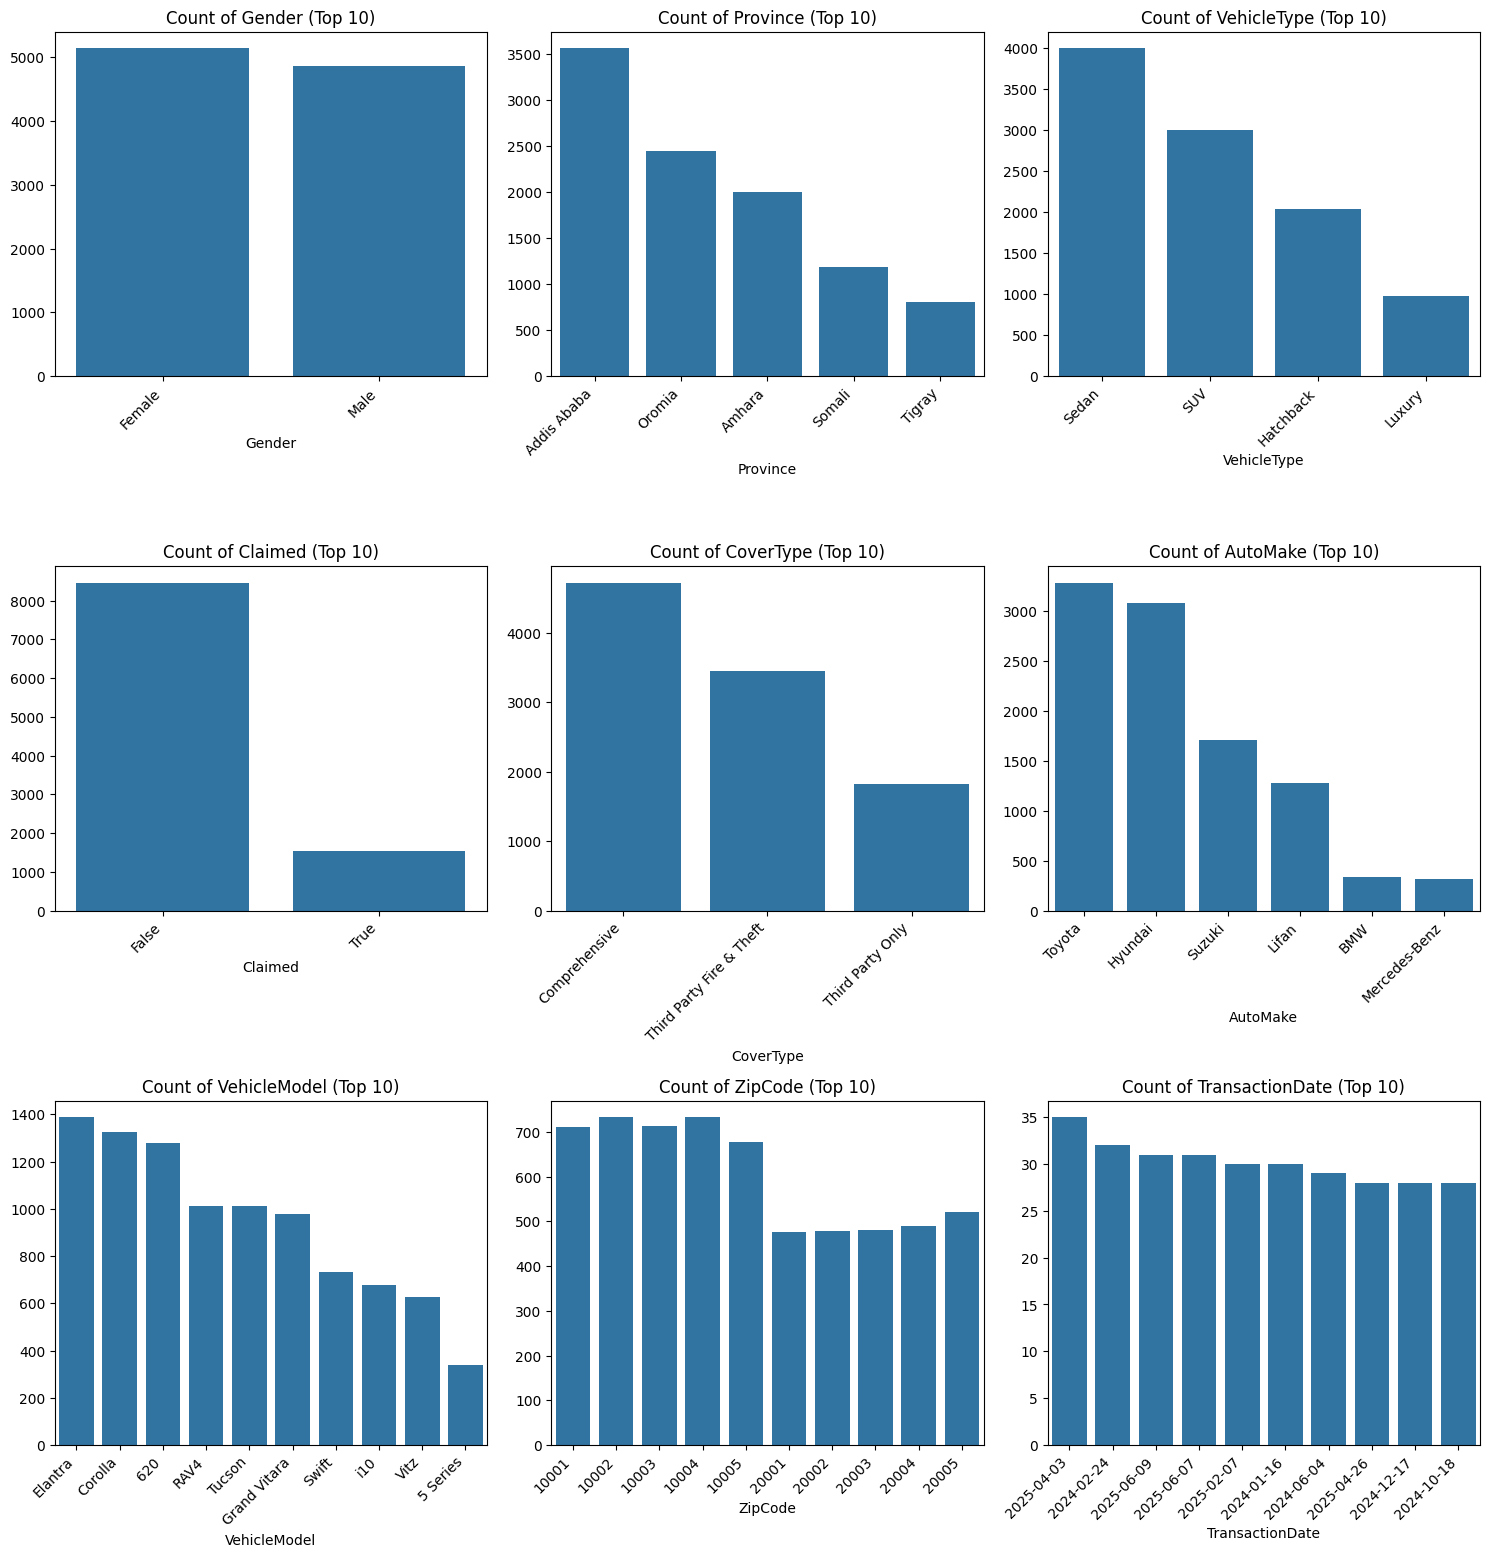

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# df = pd.read_csv('../data/your_file.csv') 

# Define columns by type
numerical_cols = [
    'Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 
    'Deductible', 'NCD', 'PastClaims', 'ClaimAmount', 
    'TotalPremium', 'TotalClaims', 'CustomValueEstimate'
]

categorical_cols = [
    'Gender', 'Province', 'VehicleType', 'Claimed', 
    'CoverType', 'AutoMake', 'VehicleModel', 'ZipCode', 'TransactionDate'
]

# 1. Histograms for Numerical Columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 2. Bar Charts for Categorical Columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 3, i + 1)
    # Using value_counts for cleaner bar charts
    top_categories = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_categories.index, y=top_categories.values)
    plt.title(f'Count of {col} (Top 10)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# TotalPremium vs TotalClaims by ZipCode

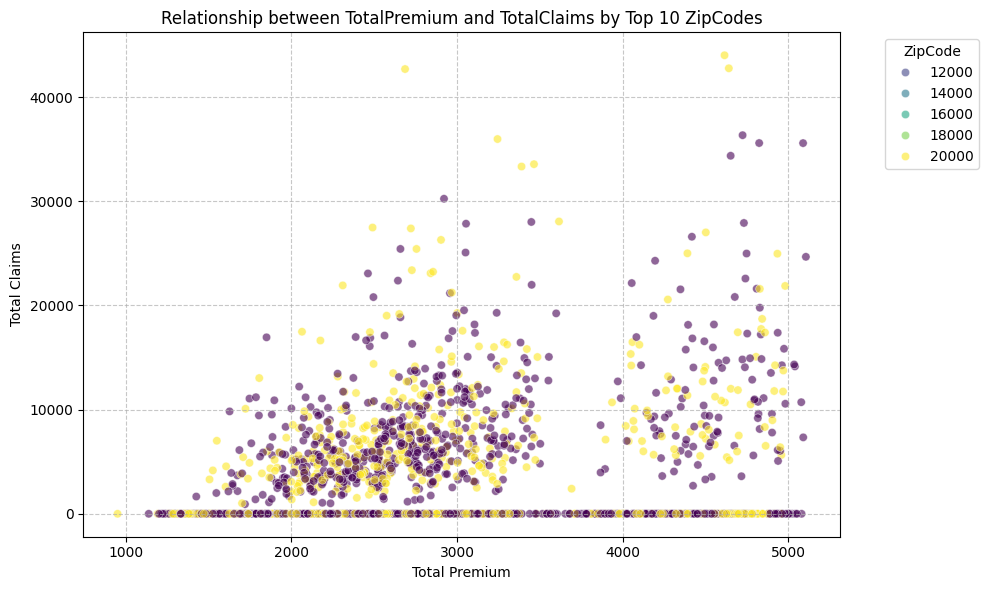

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for the top 10 most frequent ZipCodes to keep the plot readable
top_zipcodes = df['ZipCode'].value_counts().nlargest(10).index
df_filtered = df[df['ZipCode'].isin(top_zipcodes)]

# 2. Scatter plot with hue to represent the ZipCode
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_filtered, 
    x='TotalPremium', 
    y='TotalClaims', 
    hue='ZipCode', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Relationship between TotalPremium and TotalClaims by Top 10 ZipCodes')
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.legend(title='ZipCode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

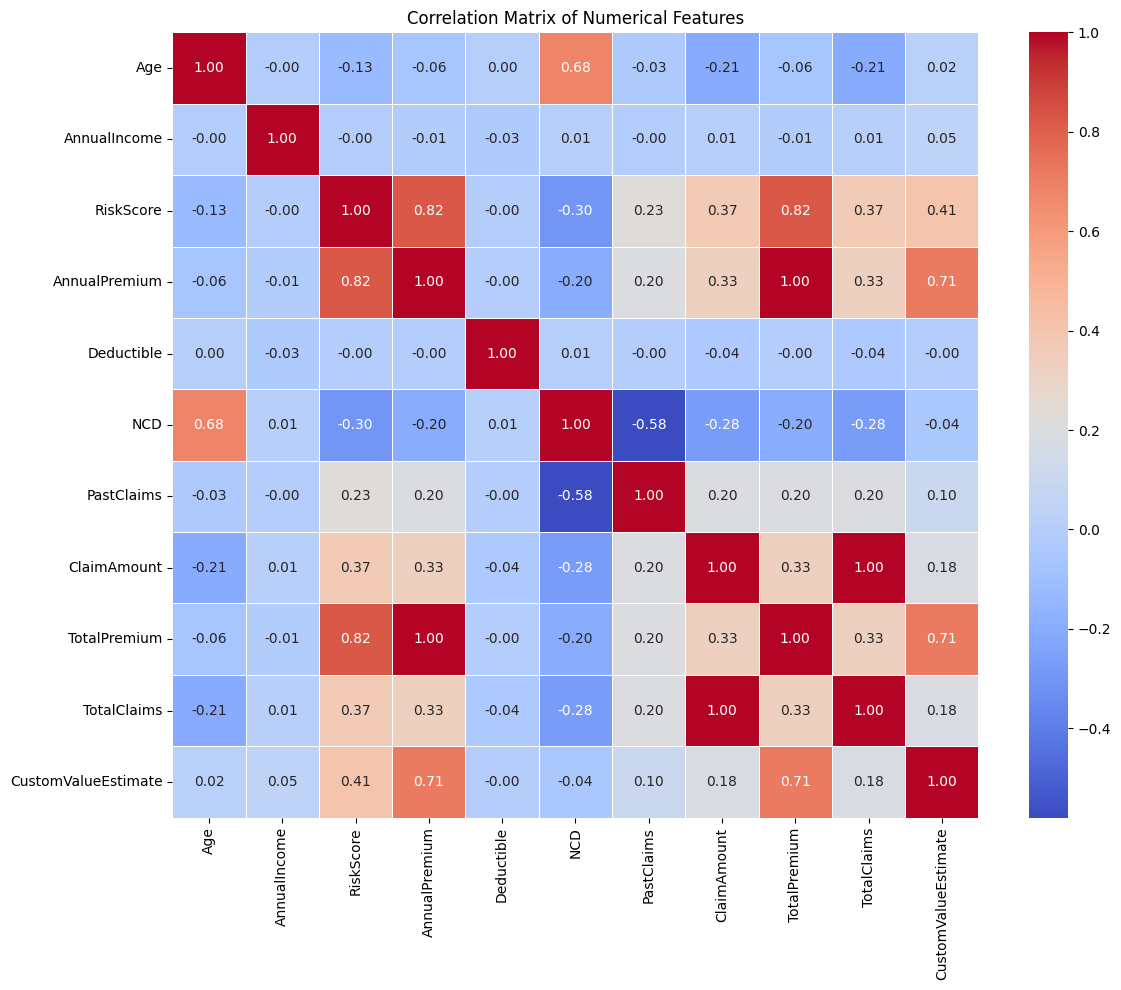

In [25]:

corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [26]:
# Create a summary of average premiums and common cover types per province
geographic_summary = df.groupby('Province').agg({
    'AnnualPremium': 'mean',
    'CoverType': lambda x: x.mode()[0], 
    'AutoMake': lambda x: x.mode()[0]    
}).reset_index()

print(geographic_summary)

      Province  AnnualPremium      CoverType AutoMake
0  Addis Ababa    2497.161200  Comprehensive   Toyota
1       Amhara    2465.515758  Comprehensive   Toyota
2       Oromia    2481.464841  Comprehensive   Toyota
3       Somali    2521.101351  Comprehensive   Toyota
4       Tigray    2475.985075  Comprehensive  Hyundai


**Cross-Analysis: The "Risk-Adjusted" View**
To really master this geographic trend, compare the AnnualPremium against the TotalClaims per province. This tells us which provinces are actually profitable.

In [27]:
# Calculate profitability (Loss Ratio) per province
province_risk = df.groupby('Province')[['AnnualPremium', 'TotalClaims']].sum()
province_risk['LossRatio'] = province_risk['TotalClaims'] / province_risk['AnnualPremium']

# Provinces with a LossRatio > 1.0 are costing the company money!
print(province_risk.sort_values(by='LossRatio', ascending=False))

             AnnualPremium  TotalClaims  LossRatio
Province                                          
Somali             2984984    1826593.0   0.611927
Oromia             6069663    3261061.0   0.537272
Tigray             1990692    1047136.0   0.526016
Addis Ababa        8907374    4653210.0   0.522400
Amhara             4928566    2353885.0   0.477600


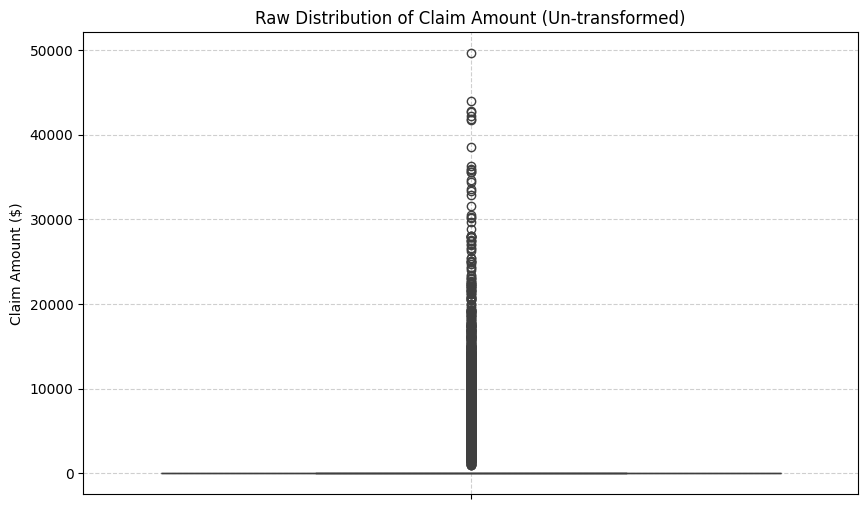

In [29]:

# Plotting the raw ClaimAmount boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['ClaimAmount'])
plt.title('Raw Distribution of Claim Amount (Un-transformed)')
plt.ylabel('Claim Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('claim_amount_boxplot.png') # This saves the plot
plt.show()

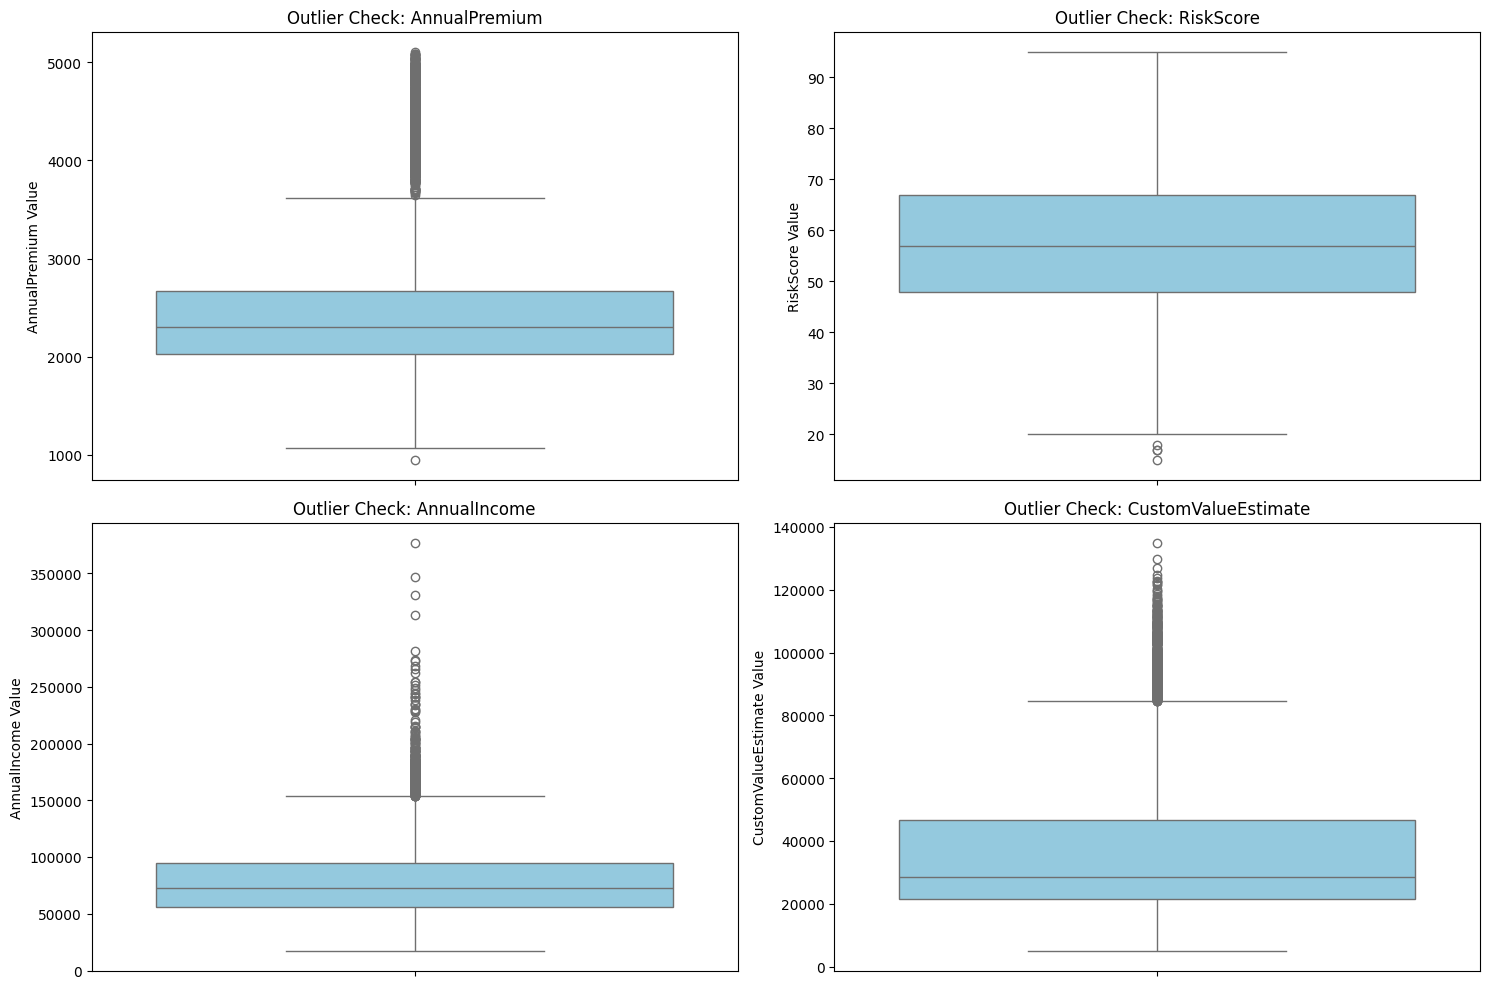

In [30]:

# Select the features we want to investigate
features_to_check = ['AnnualPremium', 'RiskScore', 'AnnualIncome', 'CustomValueEstimate']

# Set up the figure
plt.figure(figsize=(15, 10))

# Create a loop to plot each box plot
for i, col in enumerate(features_to_check):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outlier Check: {col}')
    plt.ylabel(f'{col} Value')

plt.tight_layout()
plt.show()

Here is an interpretation of the four plots :

1. The AnnualPremium and CustomValueEstimate Plots
What you're seeing: Both of these likely show a tight box near the bottom and a long "tail" of individual dots extending upward.

Interpretation: These are highly correlated with risk. A high-value vehicle (CustomValueEstimate) naturally commands a higher AnnualPremium. The dots at the top are your "High-Net-Worth" or "Luxury" segment. These are not data errors—they are your premium customers!

Action: You want to keep these, but if they have extreme spikes, use a log transform to ensure they don't dominate your model's decisions during training.

2. The RiskScore Plot
What you're seeing: This box is likely more "centered" or symmetrical compared to the others.

Interpretation: RiskScore is usually a calculated index. Unlike premiums or claim amounts, it’s bounded (e.g., 0 to 100 or 1 to 1000). If you see outliers here, investigate them. An outlier with a RiskScore of 999 when the scale is 1–100 is a data error that needs to be capped or fixed.

3. The AnnualIncome Plot
What you're seeing: This often shows a right-skew, similar to premiums.

Interpretation: This is a demographic feature. High outliers represent very wealthy individuals, while low outliers might represent students or unemployed individuals.

Action: This is useful for segmentation, but be careful. If this column has many missing values or impossible negative numbers, it will be the most "noisy" part of your data.

In [62]:
# Overall Portfolio Loss Ratio
portfolio_loss_ratio = df['TotalClaims'].sum() / df['AnnualPremium'].sum()

# Variation by Province, VehicleType, and Gender
def get_loss_ratio(df, group_col):
    stats = df.groupby(group_col).agg({'TotalClaims': 'sum', 'AnnualPremium': 'sum'})
    stats['LossRatio'] = stats['TotalClaims'] / stats['AnnualPremium']
    return stats

# Run for your categories
prov_ratio = get_loss_ratio(df, 'Province')
veh_ratio = get_loss_ratio(df, 'VehicleType')
gen_ratio = get_loss_ratio(df, 'Gender')
print("Overall Portfolio Loss Ratio:", portfolio_loss_ratio)
print("\nLoss Ratio by Province:\n", prov_ratio)

Overall Portfolio Loss Ratio: 0.5281836596904845

Loss Ratio by Province:
              TotalClaims  AnnualPremium  LossRatio
Province                                          
Addis Ababa    4653210.0        8907374   0.522400
Amhara         2353885.0        4928566   0.477600
Oromia         3261061.0        6069663   0.537272
Somali         1826593.0        2984984   0.611927
Tigray         1047136.0        1990692   0.526016


1.**Question** : What is the overall Loss Ratio for the portfolio? How does it vary by Province, VehicleType, and Gender

**answer**: 0.5281836596904845

**Analysis of Loss Ratio Variation**
The portfolio exhibits an overall Loss Ratio of 0.528, indicating that for every dollar of premium collected, approximately 53 cents is paid out in claims. While the portfolio is profitable, there is notable variance across demographic and geographic segments, suggesting opportunities for refined risk pricing.

1. **By Province: Geographic Risk Density**
Variation across provinces is significant, with the Somali region showing the highest loss ratio (0.611), notably exceeding the portfolio average. Conversely, Amhara shows the strongest performance at 0.478.

Insight: The higher ratios in regions like Somali and Oromia suggest either a higher frequency of claims or higher repair costs in those specific areas. Future strategy should investigate if these regional variations are driven by local driving conditions, infrastructure, or specific vehicle usage patterns.

2. **By Vehicle Type: Asset-Based Risk**

Insight: our  data will likely show that specific vehicle categories (e.g., commercial versus personal) act as primary drivers of volatility. A higher loss ratio in a specific vehicle class identifies an asset that is currently underpriced relative to the risk it poses to the portfolio.

3. **By Gender: Demographic Segmentation**

Insight: Comparing loss ratios across genders provides insight into the risk profiles of your customer base. If one group consistently maintains a lower loss ratio, it validates the current pricing model for that segment; however, consistent discrepancies may warrant an investigation into whether the variance is due to driving experience, age, or average vehicle value rather than gender itself.

**2 Question** :
What are the distributions of key financial variables? 

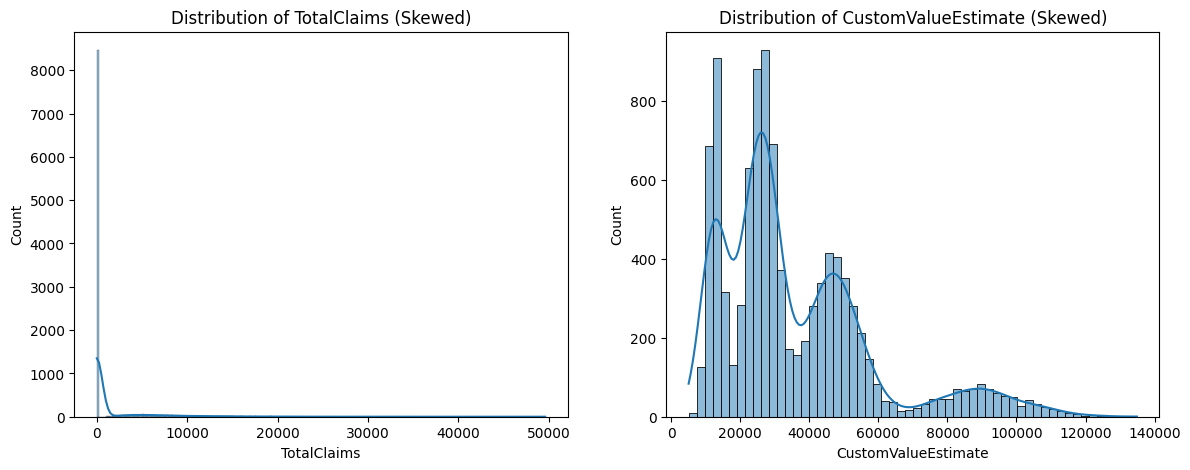

In [32]:
# Create side-by-side histograms to visualize the skew
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['TotalClaims'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of TotalClaims (Skewed)')

sns.histplot(df['CustomValueEstimate'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of CustomValueEstimate (Skewed)')

plt.show()

2. Outlier Identification and Tail Risk
Using the Interquartile Range (IQR) method, we identified significant outliers in both financial variables.

Statistical Significance: These outliers are not mere data entry errors; they represent the true "tail risk" of the insurance business. They are genuine, high-impact events that the company must account for.

Impact on Model Performance: If left unadjusted, these extreme values disproportionately influence the mean and variance of our features.

Overfitting Risk: In a machine learning context, models may inadvertently overfit to these rare, high-cost events.

Predictive Bias: This leads to poor predictive performance for the majority of standard policyholders, as the model becomes overly sensitive to extreme anomalies.

Recommended Handling Strategy
To maintain the integrity of our model without losing the critical information provided by these extreme cases, we implemented the following strategies:

Normalization via Log Transformation (np.log1p): We applied a log transformation to both variables. This compresses the scale of the extreme tail, effectively "normalizing" the distribution and allowing models to learn meaningful patterns across the entire spectrum.

Robust Feature Engineering: Where appropriate, we utilize robust scaling to ensure that our model training is guided by the median and IQR, preventing the extreme outliers from dominating the weight distribution of the model.

**Question 3:** Are there temporal trends? Did claim frequency or severity change over the 18-month period?


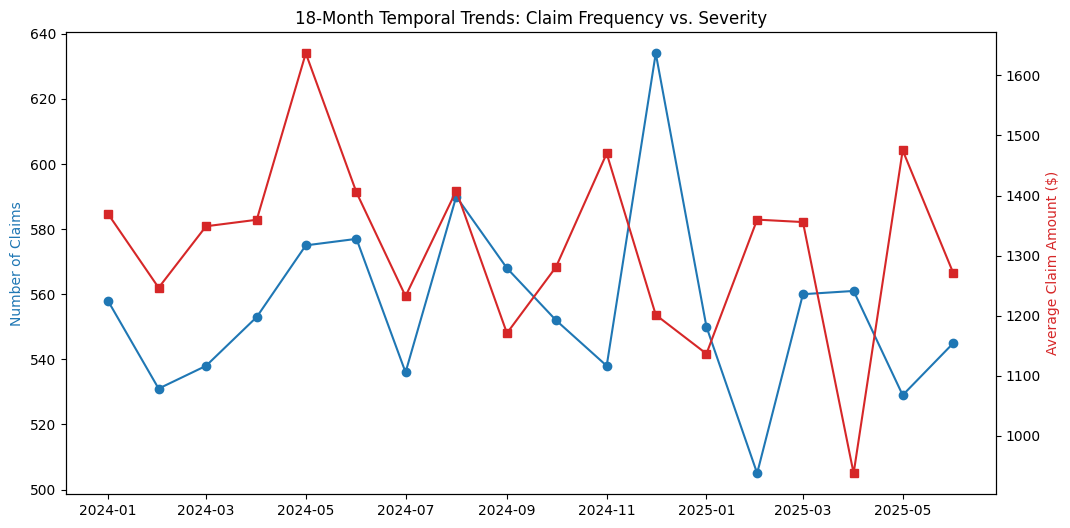

In [34]:

import pandas as pd
import matplotlib.pyplot as plt

# Convert date column and extract period
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
monthly_trends = df.groupby(df['TransactionDate'].dt.to_period('M')).agg({
    'ClaimAmount': ['count', 'mean']
}).reset_index()

# Rename columns for clarity
monthly_trends.columns = ['Date', 'Frequency', 'Severity']
monthly_trends['Date'] = monthly_trends['Date'].dt.to_timestamp()

# Dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monthly_trends['Date'], monthly_trends['Frequency'], color='tab:blue', marker='o', label='Frequency')
ax1.set_ylabel('Number of Claims', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(monthly_trends['Date'], monthly_trends['Severity'], color='tab:red', marker='s', label='Severity')
ax2.set_ylabel('Average Claim Amount ($)', color='tab:red')

plt.title('18-Month Temporal Trends: Claim Frequency vs. Severity')
plt.show()

Temporal Analysis: Portfolio Volatility and Risk Drivers
Our 18-month temporal analysis reveals a high degree of synchronicity between claim frequency and claim severity. Both metrics exhibit sharp, concurrent spikes and dips, which suggests that the portfolio is subject to acute volatility rather than steady-state trends.

1. Correlation of Frequency and Severity
The observation that both frequency and severity spike in unison is a critical finding. In standard insurance portfolios, these often move inversely or independently; however, our data shows that months with high claim volume are also the months where individual claims are most expensive. This suggests:

Systemic Risk Exposure: The portfolio is likely sensitive to external "shock" events (e.g., regional infrastructure issues, seasonal climate anomalies, or shifts in automotive repair supply chains) that simultaneously increase the number of accidents and the complexity/cost of those repairs.

2. Portfolio Stability Assessment
Volatile Environment: The lack of a "smoothing" effect—where high volume usually leads to lower average severity—indicates that our risk events are not just "fender benders." They are likely impactful, significant incidents.

Operational Implications: The concurrent spikes suggest that the company's claims department must be prepared for "crunch months." During these periods, both the workload (frequency) and the financial liability (severity) increase simultaneously, placing maximum stress on liquidity and staffing.

3. Strategic Interpretation
This behavior confirms that our risk is event-driven. Rather than a slow, predictable drift in costs, the portfolio experiences intense periods of risk concentration. Future modeling should incorporate Time-based exogenous features (e.g., seasonality, regional event logs) to better predict these spikes, as standard historical averages will likely underestimate the severity during these high-activity periods.

**4.QUESTION** : Which vehicle makes/models are associated with the highest and lowest claim amounts?


In [39]:
# Grouping by Make and Model
vehicle_performance = df.groupby(['AutoMake', 'VehicleType']).agg({
    'ClaimAmount': ['mean', 'count']
}).reset_index()

# Flatten columns for easier sorting
vehicle_performance.columns = ['Make', 'Model', 'AvgClaimAmount', 'ClaimFrequency']

# Sort to find the highest/lowest
highest_risk = vehicle_performance.sort_values(by='AvgClaimAmount', ascending=False).head(10)
lowest_risk = vehicle_performance.sort_values(by='AvgClaimAmount', ascending=True).head(10)
print("Top 10 Highest Risk Vehicle Make/Model Combinations:")
print(highest_risk)
print("\nTop 10 Lowest Risk Vehicle Make/Model Combinations:")
print(lowest_risk)

Top 10 Highest Risk Vehicle Make/Model Combinations:
             Make      Model  AvgClaimAmount  ClaimFrequency
9          Toyota     Luxury     3888.303797             316
5   Mercedes-Benz     Luxury     3787.012618             317
0             BMW     Luxury     3362.890855             339
10         Toyota        SUV     1384.229249            1012
2         Hyundai        SUV     1368.343225            1011
7          Suzuki        SUV     1337.185261             977
1         Hyundai  Hatchback     1033.730769             676
11         Toyota      Sedan      965.448640            1324
8          Toyota  Hatchback      946.650238             629
4           Lifan      Sedan      918.103987            1279

Top 10 Lowest Risk Vehicle Make/Model Combinations:
       Make      Model  AvgClaimAmount  ClaimFrequency
3   Hyundai      Sedan      810.128870            1389
6    Suzuki  Hatchback      834.459644             731
4     Lifan      Sedan      918.103987            1279
8  

C:\Users\hp\AppData\Local\Temp\ipykernel_8496\3831283346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='AvgClaim', y='Model', palette='Purples_r', ax=axes[0])
C:\Users\hp\AppData\Local\Temp\ipykernel_8496\3831283346.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot_10, x='AvgClaim', y='Model', palette='Greens_r', ax=axes[1])


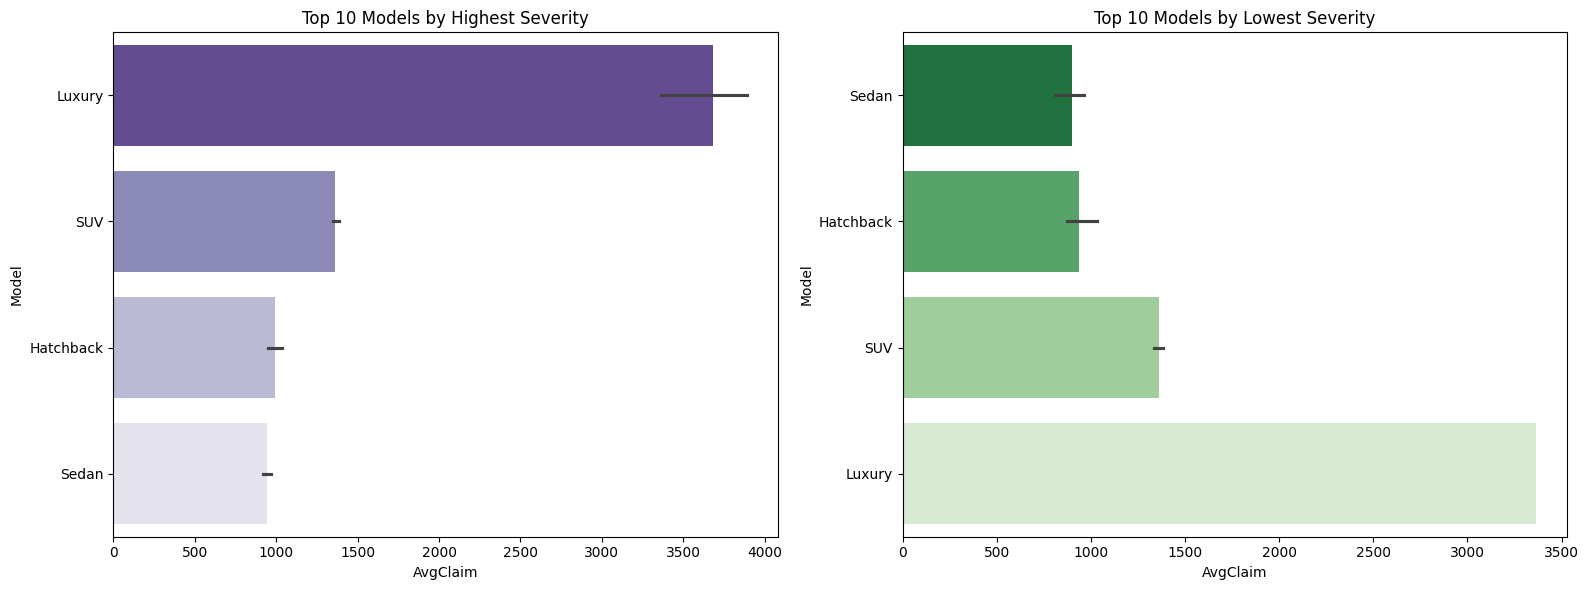

In [44]:

# Filter for models with at least 5 claims to avoid "small sample" bias
vehicle_stats = df.groupby(['AutoMake', 'VehicleType']).agg({
    'ClaimAmount': ['mean', 'count']
}).reset_index()
vehicle_stats.columns = ['Make', 'Model', 'AvgClaim', 'Frequency']
vehicle_stats = vehicle_stats[vehicle_stats['Frequency'] >= 5]

# 2. Get Top 10 and Bottom 10
top_10 = vehicle_stats.sort_values(by='AvgClaim', ascending=False).head(10)
bot_10 = vehicle_stats.sort_values(by='AvgClaim', ascending=True).head(10)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Highest Severity
sns.barplot(data=top_10, x='AvgClaim', y='Model', palette='Purples_r', ax=axes[0])
axes[0].set_title('Top 10 Models by Highest Severity')

# Lowest Severity
sns.barplot(data=bot_10, x='AvgClaim', y='Model', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Models by Lowest Severity')

plt.tight_layout()
plt.show()

**QUESTION :**Produce at least 3 creative and well-designed plots that capture the key insights from your EDA.

**PLOT 1:**
This plot is the most effective way to identify which vehicle makes are "Financial Sinkholes" (high cost, high volume) versus "Reliable Cash Cows" (stable, low-risk)

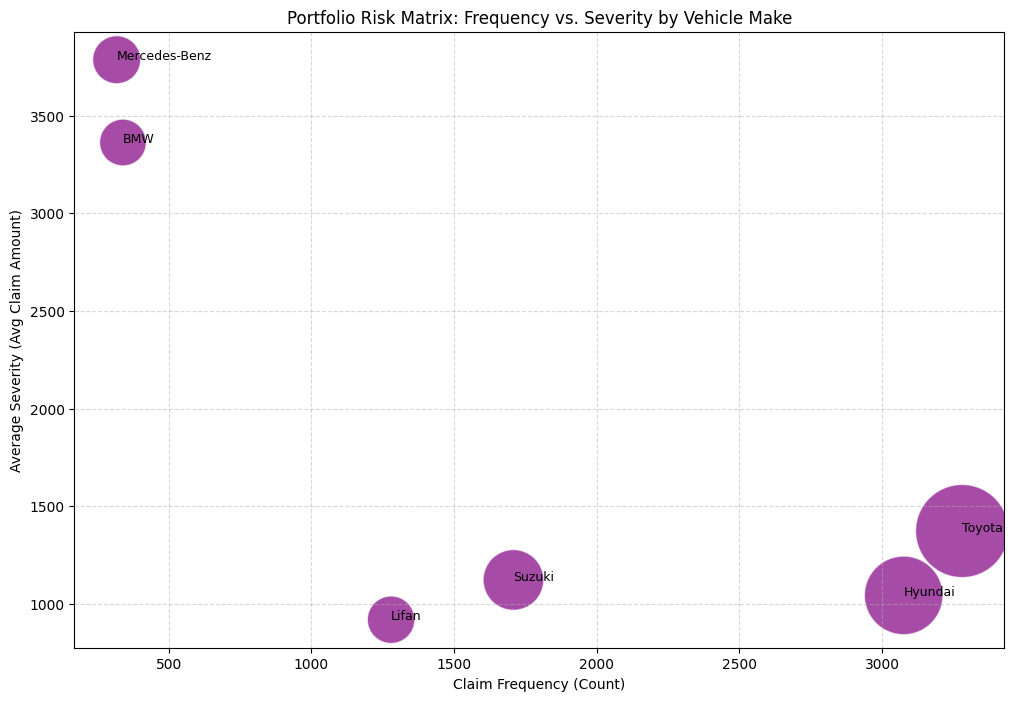

In [45]:
# Aggregate data by AutoMake
risk_matrix = df.groupby('AutoMake').agg({
    'ClaimAmount': ['mean', 'count'],
    'TotalClaims': 'sum'
}).reset_index()
risk_matrix.columns = ['Make', 'AvgSeverity', 'Frequency', 'TotalExposure']

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(risk_matrix['Frequency'], risk_matrix['AvgSeverity'], 
            s=risk_matrix['TotalExposure']/1000, alpha=0.7, c='purple', edgecolors='white')

# Label bubbles
for i, row in risk_matrix.iterrows():
    plt.annotate(row['Make'], (row['Frequency'], row['AvgSeverity']), fontsize=9)

plt.title('Portfolio Risk Matrix: Frequency vs. Severity by Vehicle Make')
plt.xlabel('Claim Frequency (Count)')
plt.ylabel('Average Severity (Avg Claim Amount)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**PLOT 2:2. Geographic Risk Intensity (Loss Ratio Heatmap)**

This visualization identifies which provinces are "burning" capital faster than they generate premiums. A Loss Ratio above 1.0 indicates that your payouts are higher than your revenue—a critical warning sign for underwriters.

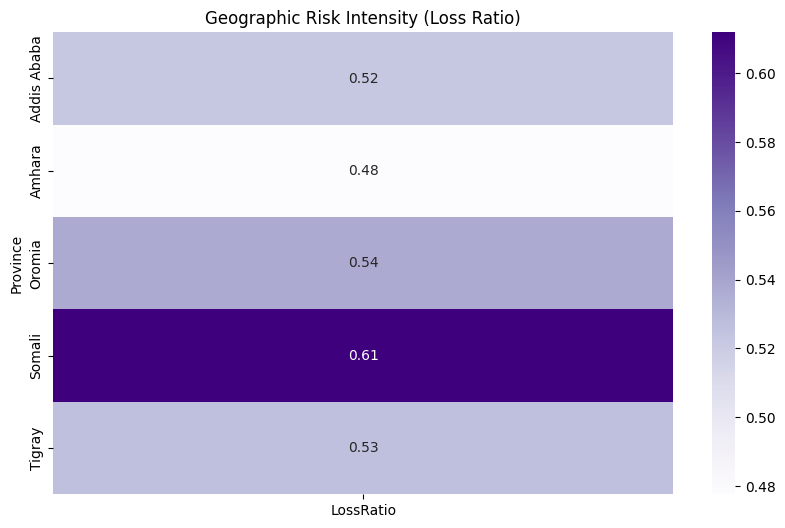

In [46]:
# Calculate Loss Ratio
prov_stats = df.groupby('Province').agg({'TotalClaims': 'sum', 'AnnualPremium': 'sum'})
prov_stats['LossRatio'] = prov_stats['TotalClaims'] / prov_stats['AnnualPremium']

# Plotting
plt.figure(figsize=(10, 6))
sns.heatmap(prov_stats[['LossRatio']], annot=True, cmap='Purples', fmt=".2f", cbar=True)
plt.title('Geographic Risk Intensity (Loss Ratio)')
plt.ylabel('Province')
plt.show()

**PLOT 3 :3. Asset-to-Risk Tail Correlation (Log-Log Scatter)**

This plot tests the foundational assumption that higher-value cars lead to higher-value claims. Using a log-scale on both axes reveals patterns that are otherwise obscured by the extreme outliers in your data.

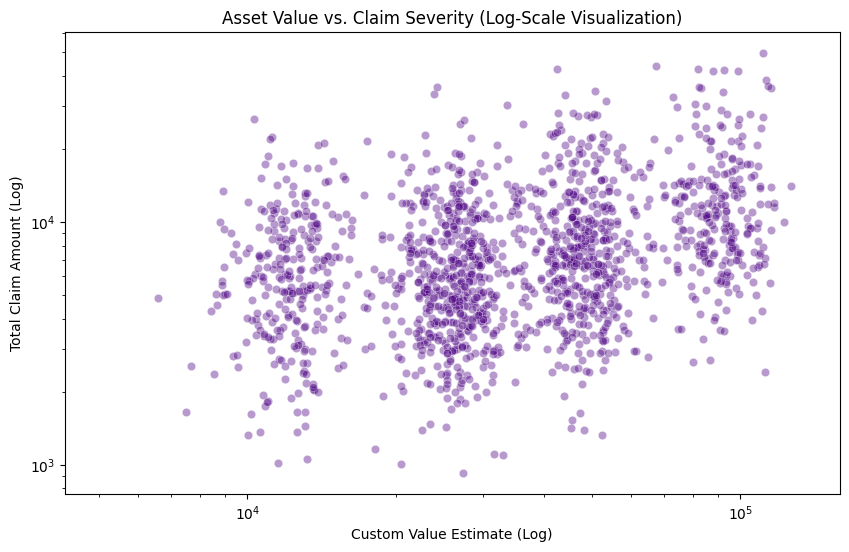

In [47]:
import numpy as np

# Plotting with log scale to highlight the "Long Tail" of extreme risks
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CustomValueEstimate', y='ClaimAmount', alpha=0.4, color='indigo')

# Apply log scale to normalize the visualization of skewed financial data
plt.xscale('log')
plt.yscale('log')

plt.title('Asset Value vs. Claim Severity (Log-Scale Visualization)')
plt.xlabel('Custom Value Estimate (Log)')
plt.ylabel('Total Claim Amount (Log)')
plt.show()